# Trustpilot reviews of Trustpilot (2021 sample): data exploration

The dataset is a random sample of reviews left on Trustpilot **about Trustpilot itself**. Each row has seven fields:

| Field | Meaning |
|---|---|
| `review_id` | unique identifier for the review |
| `created_date` | when the review was left |
| `stars` | star rating, 1–5 |
| `Title` | headline text |
| `Text` | review body |
| `source` | how, and whether, the reviewer was invited to leave the review |
| `language` | language the review was written in |

**Outline**
1. Load and check data quality
2. Clean
3. Star ratings
4. Review source (invited vs organic)
5. Language
6. Time
7. Review text: length and structure
8. Themes in the text (English reviews)
9. Key findings, caveats and next steps

In [1]:
import html
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DATA = ROOT / "Data_Advisory_Random_Sample_tp_2021 (3) (1).csv"

# Chart styling: light surface, thin hairline grid, muted axes.
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE = "#2a78d6", "#eb6834"
# Diverging blue <-> red with a neutral gray midpoint: 1★ = red, 3★ = gray, 5★ = blue.
STAR_COLORS = {1: "#e34948", 2: "#f0a09f", 3: "#c3c2b7", 4: "#86b6ef", 5: "#2a78d6"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "lines.linewidth": 2,
})


def star_mix_chart(mix, counts, title, ax=None):
    """100% stacked horizontal bars of the star mix per group, with n beside each label."""
    ax = ax or plt.gca()
    left = np.zeros(len(mix))
    labels = [f"{g}  (n={counts[g]:,})" for g in mix.index]
    for s in [1, 2, 3, 4, 5]:
        vals = mix[s].to_numpy()
        ax.barh(labels, vals, left=left, color=STAR_COLORS[s], edgecolor=SURFACE, linewidth=1.5,
                height=0.7, label=f"{s}★")
        for y, (l, v) in enumerate(zip(left, vals)):
            if s in (1, 5) and v >= 0.08:  # label only the poles, and only where it fits
                ax.text(l + v / 2, y, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                        color="white" if s == 5 else INK)
        left += vals
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, 1)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    ax.legend(ncol=5, loc="upper left", bbox_to_anchor=(0, -0.08), fontsize=9, handlelength=1)
    return ax

## 1. Load and check data quality

In [2]:
raw = pd.read_csv(DATA)
print(raw.shape)
raw.head()

(10000, 7)


,review_id,created_date,stars,Title,Text,source,language
0,619a548bbd63dda48260135f,2021-11-21 14:15:39 UTC,1,Up&#229;lidelige anmelders,Har en virksomhed med over 25000 ordre over 5 &#229;r. Glimrende virksomhed hvor mine kunder ligger millioner af kroner og alle vores kunder f&#229;r deres ...,organic,da
1,616c06eb234f1b1fe55c71ee,2021-10-17 11:20:11 UTC,5,Спасибо,Просто спасибо за вашу работу и ваш сервис. Мне стало легче,invitationlinkapi,ru
2,61b70dae0b7cbbcbfe0aa25c,2021-12-13 09:09:02 UTC,5,Trov&#230;rdig og p&#229;lidelig,Trov&#230;rdig og p&#229;lidelig,invitationlinkapi,da
3,61096517f9f487044c505e90,2021-08-03 15:47:35 UTC,1,Trust pilot unreliable,"Trust pilot contributed to me investing in a scam that cost me a fair bit of money. Even after many complaints by other customers, trust pilot failed and is...",invitationlinkapi,en
4,60edfae6f9f487033082d1da,2021-07-13 20:43:18 UTC,5,Merci......,Merci......,organic,fr


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review_id     10000 non-null  str  
 1   created_date  10000 non-null  str  
 2   stars         10000 non-null  int64
 3   Title         9999 non-null   str  
 4   Text          9999 non-null   str  
 5   source        10000 non-null  str  
 6   language      10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 547.0 KB


In [4]:
created = pd.to_datetime(raw["created_date"], utc=True)
entity = r"&#?\w+;"

quality = pd.Series({
    "rows": len(raw),
    "duplicate review_id": raw["review_id"].duplicated().sum(),
    "fully duplicated rows": raw.duplicated().sum(),
    "missing Title": raw["Title"].isna().sum(),
    "missing Text": raw["Text"].isna().sum(),
    "Title with HTML entities (e.g. &#229;)": raw["Title"].str.contains(entity, na=False).sum(),
    "Text with HTML entities": raw["Text"].str.contains(entity, na=False).sum(),
    "stars outside 1-5": (~raw["stars"].between(1, 5)).sum(),
    "reviews dated outside 2021": (created.dt.year != 2021).sum(),
}, name="count")
quality.to_frame()

,count
rows,10000
duplicate review_id,0
fully duplicated rows,0
missing Title,1
missing Text,1
Title with HTML entities (e.g. &#229;),2127
Text with HTML entities,4319
stars outside 1-5,0
reviews dated outside 2021,1447


In [5]:
print("Date range:", created.min(), "→", created.max())
created.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index().to_frame("reviews")

Date range: 2021-07-01 02:03:33+00:00 → 2022-02-01 06:51:55+00:00


,reviews
created_date,
2021-07,1422
2021-08,1643
2021-09,1484
2021-10,1248
2021-11,1318
2021-12,1438
2022-01,1441
2022-02,6


In [6]:
print("Distinct sources:", raw["source"].nunique())
print(raw["source"].value_counts().to_string())
print()
print("Distinct language codes:", raw["language"].nunique())
print(raw["language"].value_counts().to_string())

Distinct sources: 6
source
invitationlinkapi    6745
organic              1553
basiclink            1052
invitationapi         501
afsv2                 129
domainlink             20

Distinct language codes: 42
language
en     4347
de     1544
fr     1179
da      731
it      669
nl      556
es      365
sv      188
pt      111
no       59
ru       54
pl       42
ar       34
fi       31
id       15
nb        9
ro        8
und       6
af        5
tr        5
th        4
sr        4
cs        3
hu        3
fa        3
vi        3
bn        2
gl        2
uk        2
lt        2
fy        2
ja        2
ur        1
sk        1
hi        1
lb        1
hr        1
sl        1
co        1
ca        1
tl        1
sco       1


**Data quality notes**

- **Mostly clean structurally**: 10,000 rows, unique IDs, no duplicate rows, ratings all within 1–5, only one missing title and one missing body.
- **Text is HTML-escaped**: about 20% of titles and 43% of bodies contain entities such as `&#229;` (å) or `&#39;` ('). These must be unescaped before any text work.
- **The "2021" label is loose**: reviews run from **1 July 2021 to 1 February 2022**. About 14% fall in January 2022 and 6 on 1 Feb 2022. So this is a *H2-2021 + January 2022* window, not calendar 2021.
- **Language codes need light normalising**: `no` and `nb` are both Norwegian (Bokmål), and `und` means undetermined. The long tail is thin: 42 codes, but about 99% of reviews are in the top 12.

## 2. Clean

In [7]:
SOURCE_GROUP = {
    # Reviews that came through a business invitation channel.
    "invitationlinkapi": "Invited", "invitationapi": "Invited", "afsv2": "Invited", "basiclink": "Invited",
    # Reviewer came to Trustpilot unprompted.
    "organic": "Organic",
    # Tiny and undocumented; kept apart rather than guessed.
    "domainlink": "Other",
}

df = raw.rename(columns={"Title": "title", "Text": "text"}).copy()
for col in ["title", "text"]:
    df[col] = df[col].fillna("").map(html.unescape).str.strip()
df["created_at"] = pd.to_datetime(df["created_date"], utc=True)
df["month"] = df["created_at"].dt.tz_localize(None).dt.to_period("M")
df["language"] = df["language"].replace({"nb": "no"})
df["source_group"] = df["source"].map(SOURCE_GROUP)
df["sentiment"] = pd.cut(df["stars"], [0, 2, 3, 5], labels=["negative (1-2★)", "neutral (3★)", "positive (4-5★)"])
df["text_chars"] = df["text"].str.len()
df["text_words"] = df["text"].str.split().str.len()
df["title_is_text"] = df["title"].str.casefold() == df["text"].str.casefold()

df[["review_id", "created_at", "stars", "title", "text", "source", "source_group", "language"]].head()

,review_id,created_at,stars,title,text,source,source_group,language
0,619a548bbd63dda48260135f,2021-11-21 14:15:39+00:00,1,Upålidelige anmelders,Har en virksomhed med over 25000 ordre over 5 år. Glimrende virksomhed hvor mine kunder ligger millioner af kroner og alle vores kunder får deres varer på k...,organic,Organic,da
1,616c06eb234f1b1fe55c71ee,2021-10-17 11:20:11+00:00,5,Спасибо,Просто спасибо за вашу работу и ваш сервис. Мне стало легче,invitationlinkapi,Invited,ru
2,61b70dae0b7cbbcbfe0aa25c,2021-12-13 09:09:02+00:00,5,Troværdig og pålidelig,Troværdig og pålidelig,invitationlinkapi,Invited,da
3,61096517f9f487044c505e90,2021-08-03 15:47:35+00:00,1,Trust pilot unreliable,"Trust pilot contributed to me investing in a scam that cost me a fair bit of money. Even after many complaints by other customers, trust pilot failed and is...",invitationlinkapi,Invited,en
4,60edfae6f9f487033082d1da,2021-07-13 20:43:18+00:00,5,Merci......,Merci......,organic,Organic,fr


> **Assumption on source grouping.** Trustpilot's invitation methods are the Automatic Feedback Service (`afsv2`), the Invitation API (`invitationapi`), unique invitation links (`invitationlinkapi`) and business-generated links (`basiclink`). All four are treated as *Invited*. `organic` is an unprompted review. `domainlink` (20 rows) is undocumented, so it stays as *Other*. The mapping should be confirmed with the data owner.

## 3. Star ratings

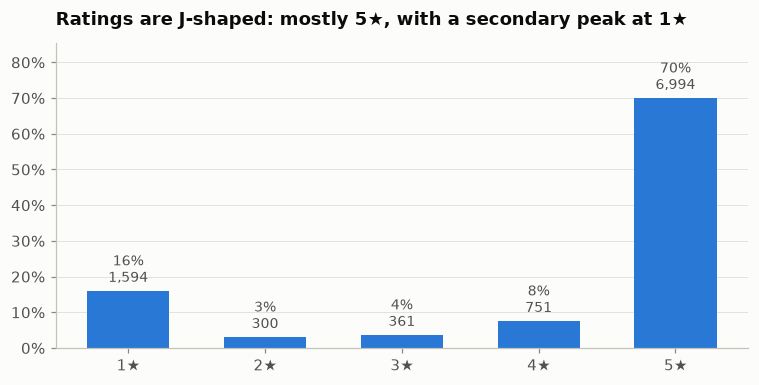

Mean rating: 4.13   Median: 5
sentiment
positive (4-5★)    0.774
negative (1-2★)    0.189
neutral (3★)       0.036


In [8]:
star_counts = df["stars"].value_counts().sort_index()
star_share = star_counts / len(df)

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(star_counts.index.astype(str) + "★", star_share, color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f"{p:.0%}\n{n:,}" for p, n in zip(star_share, star_counts)],
             padding=3, fontsize=9, color=INK_2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, star_share.max() * 1.22)
ax.grid(axis="x", visible=False)
ax.set_title("Ratings are J-shaped: mostly 5★, with a secondary peak at 1★")
plt.tight_layout()
plt.show()

print(f"Mean rating: {df['stars'].mean():.2f}   Median: {df['stars'].median():.0f}")
print(df["sentiment"].value_counts(normalize=True).round(3).to_string())

The distribution is the classic **J-shape** of online reviews. 70% are 5★ and 16% are 1★, with very little in between. A mean of about 4.1 hides how split the opinions are, so in the rest of this notebook rating *mixes* (the share at each star level) are more informative than averages.

## 4. Review source: invited vs organic

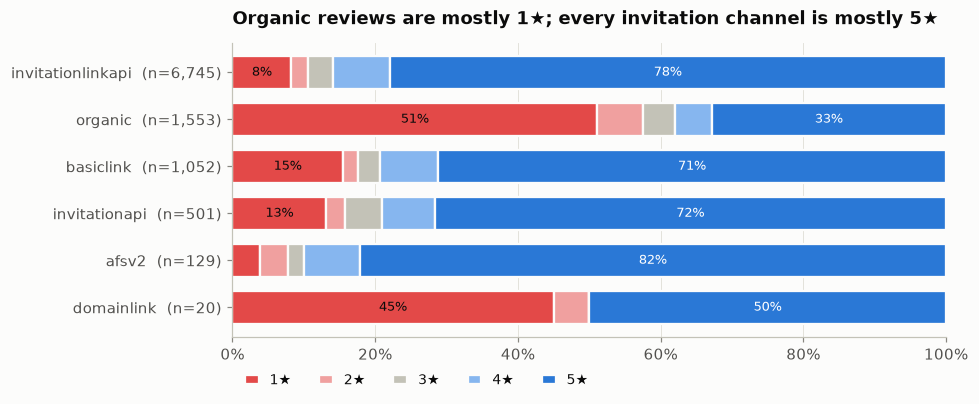

,reviews,share,group,mean_stars,pct_1star,pct_5star
afsv2,129,0.013,Invited,4.60,0.039,0.822
basiclink,1052,0.105,Invited,4.17,0.155,0.712
domainlink,20,0.002,Other,3.05,0.450,0.500
invitationapi,501,0.050,Invited,4.22,0.132,0.717
invitationlinkapi,6745,0.674,Invited,4.45,0.083,0.780
organic,1553,0.155,Organic,2.62,0.511,0.328


In [9]:
src_counts = df["source"].value_counts()
src_mix = pd.crosstab(df["source"], df["stars"], normalize="index").loc[src_counts.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
star_mix_chart(src_mix, src_counts, "Organic reviews are mostly 1★; every invitation channel is mostly 5★", ax)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "reviews": src_counts,
    "share": (src_counts / len(df)).round(3),
    "group": pd.Series(SOURCE_GROUP),
    "mean_stars": df.groupby("source")["stars"].mean().round(2),
    "pct_1star": df.groupby("source")["stars"].apply(lambda s: (s == 1).mean()).round(3),
    "pct_5star": df.groupby("source")["stars"].apply(lambda s: (s == 5).mean()).round(3),
})

In [10]:
grp = df.groupby("source_group").agg(
    reviews=("stars", "size"),
    mean_stars=("stars", "mean"),
    pct_1star=("stars", lambda s: (s == 1).mean()),
    pct_5star=("stars", lambda s: (s == 5).mean()),
    median_words=("text_words", "median"),
).round(3)
grp["share"] = (grp["reviews"] / len(df)).round(3)
grp

,reviews,mean_stars,pct_1star,pct_5star,median_words,share
source_group,,,,,,
Invited,8427,4.405,0.094,0.768,11.0,0.843
Organic,1553,2.621,0.511,0.328,39.0,0.155
Other,20,3.050,0.450,0.500,23.0,0.002


**This is the single biggest driver in the dataset.**

- **About 84% of reviews are invited.** These average 4.4★, and only 9% of them are 1★.
- **About 16% are organic.** These average 2.6★, and 51% of them are 1★. A majority of organic reviewers chose the lowest possible score.
- **Organic reviews are also about 3.5× longer** (median 39 words vs 11), so they carry most of the actual feedback text.
- **People who arrive unprompted mostly come to complain**, often about a moderation decision or about another company (see section 8). Invited reviewers rate the experience they were asked about.

Any headline score (TrustScore, average stars) therefore depends heavily on the **channel mix**. A change in how many invitations go out would move the score with no change in the underlying experience. Every later comparison (language, time) should be read with this in mind.

## 5. Language

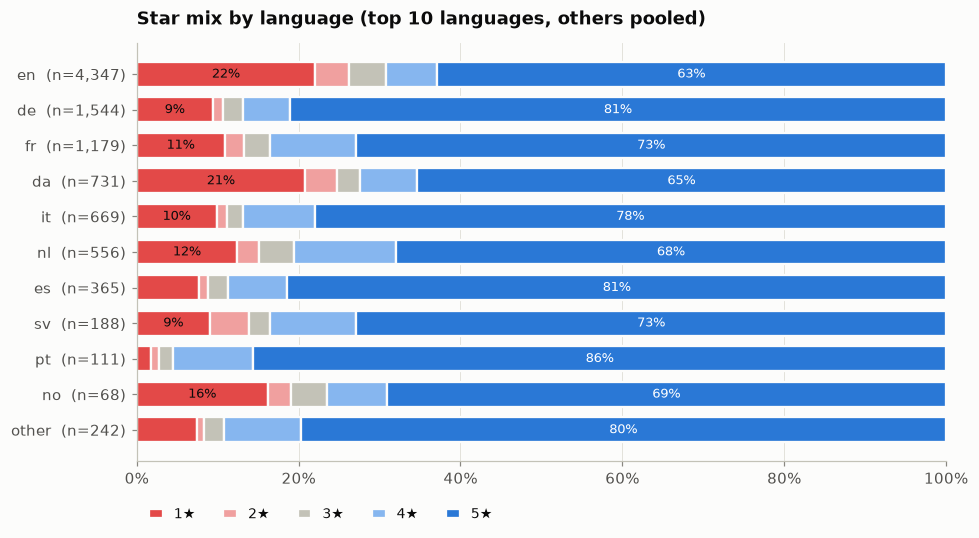

In [11]:
lang_counts = df["language"].value_counts()
top_langs = lang_counts.head(10).index
df["language_top"] = df["language"].where(df["language"].isin(top_langs), "other")
lt_counts = df["language_top"].value_counts()
order = list(top_langs) + ["other"]
lang_mix = pd.crosstab(df["language_top"], df["stars"], normalize="index").loc[order]

fig, ax = plt.subplots(figsize=(9, 5))
star_mix_chart(lang_mix, lt_counts, "Star mix by language (top 10 languages, others pooled)", ax)
plt.tight_layout()
plt.show()

In [12]:
lang_tbl = df.groupby("language_top").agg(
    reviews=("stars", "size"),
    mean_stars=("stars", "mean"),
    pct_1star=("stars", lambda s: (s == 1).mean()),
    pct_organic=("source_group", lambda s: (s == "Organic").mean()),
).loc[order].round(3)
# Rating among invited reviews only - removes the channel-mix effect.
lang_tbl["mean_stars_invited_only"] = (
    df[df["source_group"] == "Invited"].groupby("language_top")["stars"].mean().round(2)
)
lang_tbl

,reviews,mean_stars,pct_1star,pct_organic,mean_stars_invited_only
language_top,,,,,
en,4347,3.839,0.220,0.207,4.19
de,1544,4.479,0.094,0.088,4.67
fr,1179,4.323,0.109,0.085,4.43
da,731,3.922,0.208,0.234,4.50
it,669,4.438,0.099,0.120,4.67
nl,556,4.210,0.124,0.088,4.40
es,365,4.537,0.077,0.101,4.62
sv,188,4.335,0.090,0.128,4.51
pt,111,4.766,0.018,0.162,4.74


In [13]:
corr = lang_tbl[["pct_organic", "pct_1star"]].corr().iloc[0, 1]
print(f"Correlation across languages between % organic and % 1★: {corr:.2f}")

Correlation across languages between % organic and % 1★: 0.48


- **English dominates** with 43% of reviews, followed by German (15%), French (12%), Danish, Italian and Dutch.
- **English and Danish are the most negative** languages, with 22% and 21% 1★ reviews. They are also the languages with the most organic reviews (21% and 23%, against about 9% for German and French).
- **Part of the gap is channel mix.** Across languages, the share of organic reviews and the share of 1★ reviews correlate at r ≈ 0.5. Looking at invited reviews only, the spread in mean rating shrinks from about 0.9★ to about 0.55★. Danish moves from 3.9★ to 4.5★, so its low score is almost entirely mix.
- **English is still the lowest even among invited reviews** (4.19★ against 4.2–4.7★ for the other languages, with only Norwegian close). Part of this is real, and English is probably also the fallback language for reviewers from many countries.
- English reviews from non-English-speaking countries can't be separated out here because there is no country field.

## 6. Time

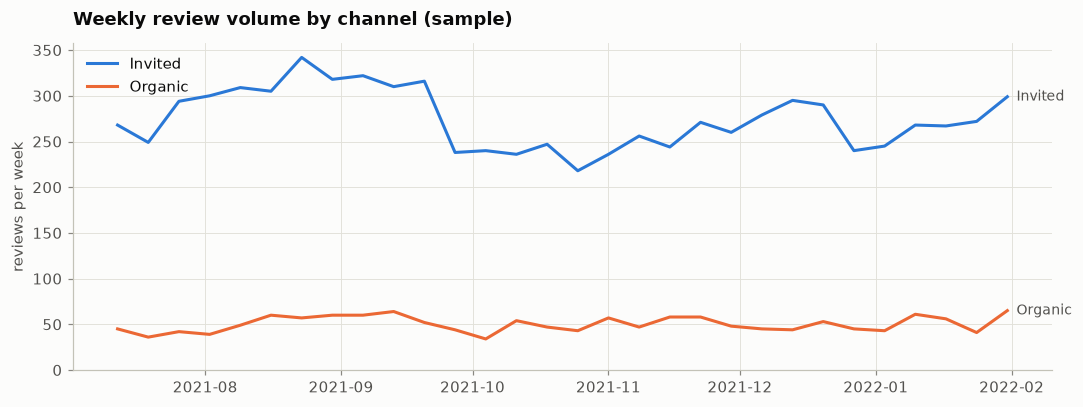

In [14]:
weekly = (df.set_index(df["created_at"].dt.tz_localize(None))
            .groupby("source_group")["stars"].resample("W-MON").size().unstack(0).fillna(0))
# Drop the partial first/last weeks so they don't read as dips.
weekly = weekly.iloc[1:-1]

fig, ax = plt.subplots(figsize=(10, 3.8))
for g, c in [("Invited", BLUE), ("Organic", ORANGE)]:
    ax.plot(weekly.index, weekly[g], color=c, label=g)
    ax.annotate(g, (weekly.index[-1], weekly[g].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=9)
ax.set_ylim(0)
ax.set_ylabel("reviews per week")
ax.set_title("Weekly review volume by channel (sample)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
monthly_all = df.assign(is_1star=df["stars"].eq(1), is_organic=df["source_group"].eq("Organic")).groupby("month").agg(
    reviews=("stars", "size"),
    mean_stars=("stars", "mean"),
    pct_1star=("is_1star", "mean"),
    pct_organic=("is_organic", "mean"),
)
monthly_all.round(3)

,reviews,mean_stars,pct_1star,pct_organic
month,,,,
2021-07,1422,4.228,0.140,0.139
2021-08,1643,4.187,0.148,0.147
2021-09,1484,4.101,0.164,0.154
2021-10,1248,4.153,0.159,0.171
2021-11,1318,4.074,0.167,0.167
2021-12,1438,4.089,0.163,0.147
2022-01,1441,4.035,0.178,0.166
2022-02,6,4.667,0.000,0.167


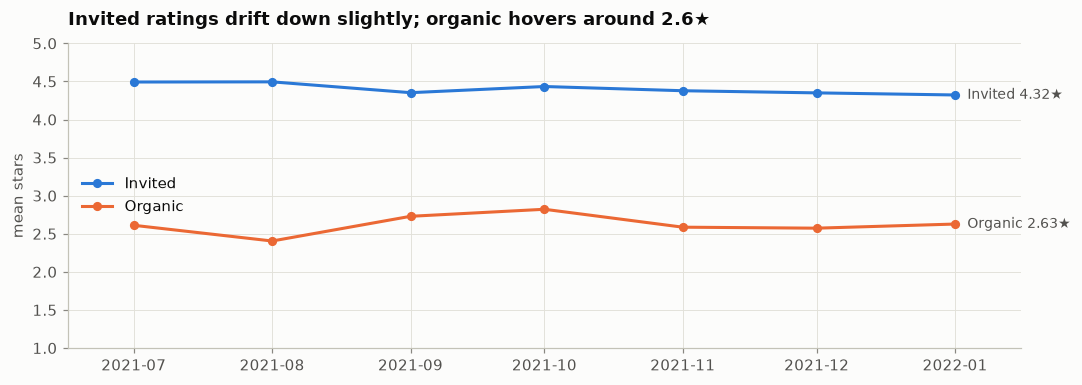

In [16]:
m = df[df["month"] < pd.Period("2022-02", "M")]  # Feb 2022 has only 6 reviews
mm = m.groupby(["month", "source_group"])["stars"].mean().unstack()
x = mm.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 3.6))
for g, c in [("Invited", BLUE), ("Organic", ORANGE)]:
    ax.plot(x, mm[g], color=c, marker="o", markersize=5, label=g)
    ax.annotate(f"{g} {mm[g].iloc[-1]:.2f}★", (x[-1], mm[g].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.set_ylim(1, 5)
ax.set_ylabel("mean stars")
ax.set_title("Invited ratings drift down slightly; organic hovers around 2.6★")
ax.legend(loc="center left")
ax.margins(x=0.08)
plt.tight_layout()
plt.show()

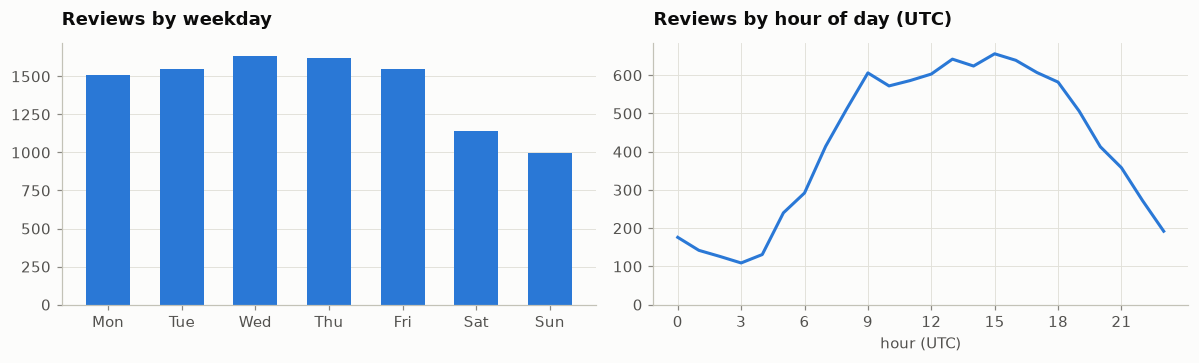

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
dow = df["created_at"].dt.day_name().value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
axes[0].bar([d[:3] for d in dow.index], dow.values, color=BLUE, width=0.6)
axes[0].grid(axis="x", visible=False)
axes[0].set_title("Reviews by weekday")

hour = df["created_at"].dt.hour.value_counts().sort_index()
axes[1].plot(hour.index, hour.values, color=BLUE)
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_ylim(0)
axes[1].set_xlabel("hour (UTC)")
axes[1].set_title("Reviews by hour of day (UTC)")
plt.tight_layout()
plt.show()

- **Invited volume moves around** (about 220–340 sampled reviews a week, with a step down at the end of September). **Organic volume is steady** at about 35–65 a week. Invitations are the controllable lever, while organic reviews are a constant background.
- **Ratings soften slightly over the period.** The overall share of 1★ reviews rises from 14% in July to 18% in January. About half of that comes from a higher organic share (14% to 17%), and half from invited ratings drifting down (4.50★ to 4.32★). Organic ratings move around 2.4–2.8★ with no trend. It is a small move over seven months and worth tracking, not a definite trend.
- **Reviews follow a working-week rhythm**: fewer on weekends, with a daytime peak around 09:00–17:00 UTC, which fits a mainly European reviewer base. Timestamps are UTC, so the hour pattern is blurred across time zones.
- Because this is a *random sample*, absolute counts reflect the sampling rate, not Trustpilot's real review volume.

## 7. Review text: length and structure

In [18]:
print(df[["text_chars", "text_words"]].describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1))

       text_chars  text_words
count     10000.0     10000.0
mean        158.2        26.8
std         264.6        44.6
min           0.0         0.0
10%          19.0         3.0
25%          33.0         6.0
50%          76.0        13.0
75%         174.0        30.0
90%         358.0        61.0
99%        1239.1       211.0
max        4780.0       778.0


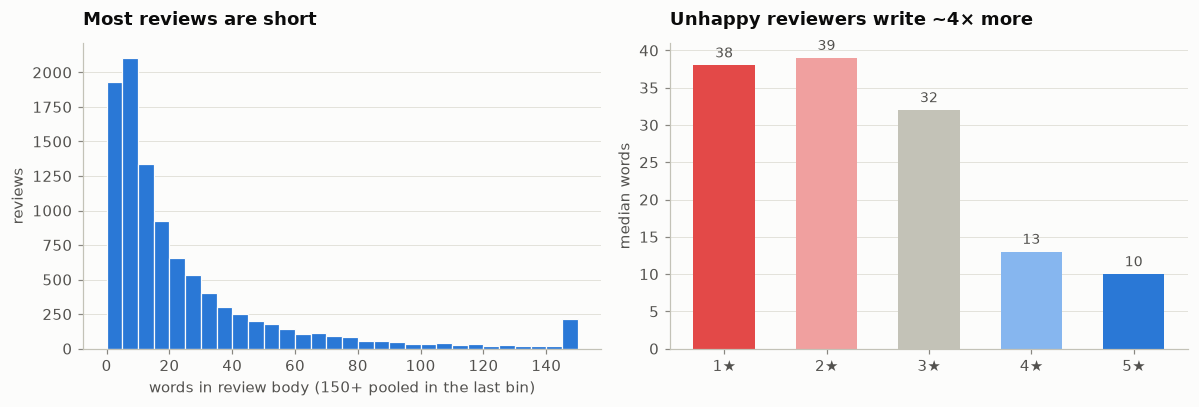

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df["text_words"].clip(upper=150), bins=range(0, 155, 5), color=BLUE, edgecolor=SURFACE, linewidth=0.8)
axes[0].set_xlabel("words in review body (150+ pooled in the last bin)")
axes[0].set_ylabel("reviews")
axes[0].set_title("Most reviews are short")
axes[0].grid(axis="x", visible=False)

med = df.groupby("stars")["text_words"].median()
b = axes[1].bar(med.index.astype(str) + "★", med.values, color=[STAR_COLORS[s] for s in med.index], width=0.6)
axes[1].bar_label(b, labels=[f"{v:.0f}" for v in med.values], padding=3, fontsize=9, color=INK_2)
axes[1].set_ylabel("median words")
axes[1].set_title("Unhappy reviewers write ~4× more")
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [20]:
print(f"Title identical to body: {df['title_is_text'].mean():.1%} of reviews")
print(pd.crosstab(df["stars"], df["title_is_text"], normalize="index").round(3)[True].rename("share title==body by stars").to_string())
print()
print("Most repeated (title, body) pairs:")
dups = df[df.duplicated(["title", "text"], keep=False)].groupby(["title", "text"]).size().sort_values(ascending=False)
print(f"{df.duplicated(['title', 'text']).sum()} reviews duplicate an earlier one word for word")
dups.head(10).to_frame("n")

Title identical to body: 19.9% of reviews
stars
1    0.068
2    0.040
3    0.078
4    0.188
5    0.242

Most repeated (title, body) pairs:
94 reviews duplicate an earlier one word for word


,,n
title,text,
Excellent service,Excellent service,13
Ottimo servizio,Ottimo servizio,10
Great service,Great service,7
Good project,Good project,4
Great service!,Great service!,4
Very helpful,Very helpful,4
Good service,Good service,4
Alles bestens.,Alles bestens.,4
Alles bestens,Alles bestens,4


- **Body length is heavily skewed.** The median review is about 13 words, but the top 1% run to several hundred.
- **Negative reviews are about 4× longer** than positive ones (a median of 38 words at 1★ against 10 at 5★). Complaints come with a story. Praise is often one line ("Great service").
- **About 20% of reviews have a title identical to the body.** This is mostly short 4–5★ invited reviews, which suggests the reviewer typed one phrase and the flow reused it. For modelling, title and body should be combined rather than treated as independent.
- **Exact duplicates** are generic praise ("Excellent service", "Ottimo servizio") from different reviewers, not spam. They are harmless for distributions but should be removed before training text models.

## 8. Themes in the text (English reviews)

These are keyword-based signals on English reviews, which are 43% of the sample. They are a quick map of what drives 1★ versus 5★ reviews, not a substitute for proper topic modelling.

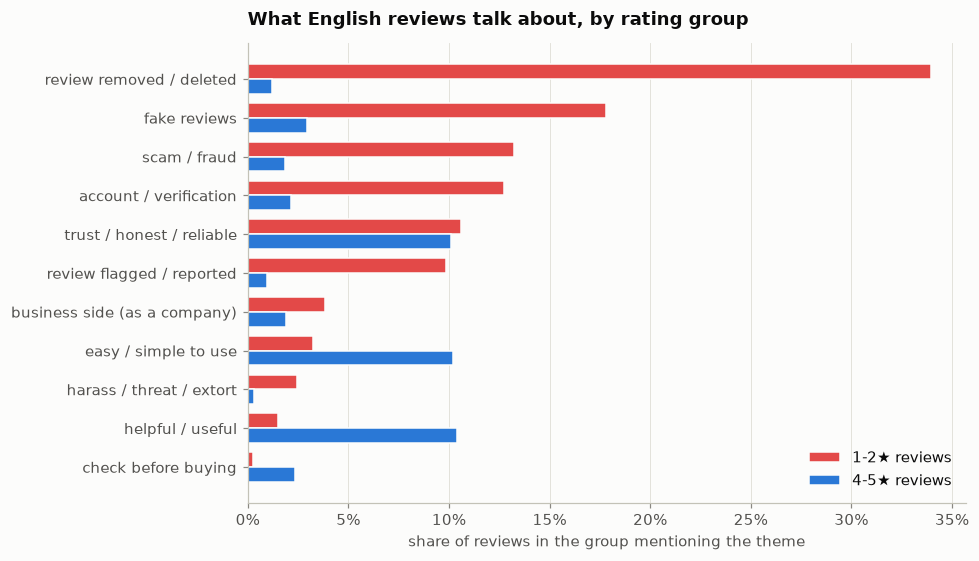

,share_of_1-2★,share_of_4-5★,mean_stars_when_mentioned,n_mentions
review removed / deleted,0.340,0.012,1.555,454
fake reviews,0.178,0.030,2.320,309
scam / fraud,0.133,0.019,2.157,216
account / verification,0.127,0.022,2.388,227
trust / honest / reliable,0.106,0.101,3.825,434
review flagged / reported,0.098,0.010,1.918,146
business side (as a company),0.039,0.019,3.186,113
easy / simple to use,0.032,0.102,4.448,355
harass / threat / extort,0.025,0.003,1.974,38
helpful / useful,0.015,0.104,4.622,347


In [21]:
en = df[df["language"] == "en"].copy()
en["full"] = (en["title"] + ". " + en["text"]).str.lower()

THEMES = {
    "review removed / deleted": r"\bremov|\bdelet|took down|taken down",
    "review flagged / reported": r"\bflag|\breport",
    "fake reviews": r"\bfake|\bbought review|paid review|\bgenuine",
    "scam / fraud": r"\bscam|\bfraud",
    "business side (as a company)": r"\bour (?:business|company|customers)|\bmy (?:business|company)\b",
    "account / verification": r"\baccount|\bverif",
    "harass / threat / extort": r"harass|threat|extort|blackmail",
    "easy / simple to use": r"\beasy|\bsimple|\buser.friendly",
    "helpful / useful": r"\bhelpful|\buseful|\bhelps? me",
    "trust / honest / reliable": r"\breliab|\bhonest|\btrustworthy|\btransparen",
    "check before buying": r"before (?:i |you )?(?:buy|purchas|order|shop)|check(?:ing)? (?:a |the )?(?:company|reviews)",
}
for name, pat in THEMES.items():
    en[name] = en["full"].str.contains(pat, regex=True)

pos, neg = en["stars"] >= 4, en["stars"] <= 2
theme_tbl = pd.DataFrame({
    "share_of_1-2★": en.loc[neg, list(THEMES)].mean(),
    "share_of_4-5★": en.loc[pos, list(THEMES)].mean(),
    "mean_stars_when_mentioned": pd.Series({t: en.loc[en[t], "stars"].mean() for t in THEMES}),
    "n_mentions": en[list(THEMES)].sum(),
}).sort_values("share_of_1-2★", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.2))
y = np.arange(len(theme_tbl))
h = 0.38
ax.barh(y + h / 2, theme_tbl["share_of_1-2★"], height=h, color=STAR_COLORS[1], label="1-2★ reviews", edgecolor=SURFACE, linewidth=1)
ax.barh(y - h / 2, theme_tbl["share_of_4-5★"], height=h, color=STAR_COLORS[5], label="4-5★ reviews", edgecolor=SURFACE, linewidth=1)
ax.set_yticks(y, theme_tbl.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title("What English reviews talk about, by rating group")
ax.set_xlabel("share of reviews in the group mentioning the theme")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

theme_tbl.sort_values("share_of_1-2★", ascending=False).round(3)

In [22]:
STOP = set("""the a an and or to of i is it in for my was that this they you have be on with not but are me at as so all
their them no just by from has can if had been very your will we do there what get any after one about would when out up more
even than which also only who our its im it's i'm don't dont were he she his her how why because then now like other some
review reviews trustpilot trust pilot company companies site website service people""".split())


def tokens(s):
    return [w for w in re.findall(r"[a-z']{3,}", s) if w not in STOP]


def bigrams(s):
    t = tokens(s)
    return [" ".join(p) for p in zip(t, t[1:])]


def distinctive(fn, n=15, min_count=8):
    """Terms most over-represented in 1-2★ vs 4-5★ (smoothed log-odds ratio)."""
    cn = Counter(w for s in en.loc[neg, "full"] for w in fn(s))
    cp = Counter(w for s in en.loc[pos, "full"] for w in fn(s))
    Nn, Np = sum(cn.values()), sum(cp.values())
    vocab = [w for w in set(cn) | set(cp) if cn[w] + cp[w] >= min_count]
    lor = pd.Series({w: np.log((cn[w] + 1) / (Nn + 1)) - np.log((cp[w] + 1) / (Np + 1)) for w in vocab})
    out = lambda ws: pd.DataFrame({"term": ws, "neg_count": [cn[w] for w in ws], "pos_count": [cp[w] for w in ws]})
    return out(lor.nlargest(n).index), out(lor.nsmallest(n).index)


neg_terms, pos_terms = distinctive(bigrams, min_count=6)
pd.concat({"most negative-leaning bigrams": neg_terms, "most positive-leaning bigrams": pos_terms}, axis=1)

most negative-leaning bigrams                     most positive-leaning bigrams                    
                            term neg_count pos_count                          term neg_count pos_count
0             genuine experience        15         0                     good good         0       131
1                  email address        39         2                     good work         0        70
2              advanced software        12         0                     keep good         0        57
3              content integrity        25         1                great platform         0        51
4                      took down        12         0                      easy use         2       152
5                 integrity team        37         2                   great great         1        95
6                  several times        11         0                  always check         0        43
7               removing genuine        10         0                      far good         0        41
8                 worst customer        10         0                      good job         0        40
9                 cannot trusted        10         0           excellent excellent         1        71
10                removed reason         9         0                  check before         0        33
11                 major mobiles         9         0                   thank thank         0        28
12                    waste time        26         2                    thank much         0        27
13              want unsubscribe         8         0                     great way         1        54
14                 keep removing         8         0            excellent platform         0        26

In [23]:
# Rough check for misdirected reviews: ones about a purchase from another company rather than Trustpilot.
other_company = en["full"].str.contains(
    r"\b(?:my order|the seller|delivery|refund|parcel|courier|the product)\b", regex=True)
print(f"English reviews mentioning orders/delivery/refunds/products: {other_company.mean():.1%} "
      f"(mean {en.loc[other_company, 'stars'].mean():.2f}★)")
en.loc[other_company & neg, ["stars", "source", "title", "text"]].sample(5, random_state=0)

English reviews mentioning orders/delivery/refunds/products: 2.5% (mean 3.30★)


,stars,source,title,text
7447,1,organic,Take down negative reviews and give a standard non individualised response.,The problem with trustpilot is that they police themselves.\nI placed 100% genuine reviews that they overzealously took down on Sunday 12th Sept before cont...
8532,1,organic,Jumping the gun,Don't you think it would be a good idea to check the product is received before requesting a follow up on said product?
6596,1,invitationapi,There is no way to prevent customers…,"There is no way to prevent customers who have not purchased from writing false reviews, and Trust Pilot's response is the worst. We ignore the trust pilot e..."
1563,1,invitationapi,Price gouging extrodinare,The product itself is ok but the way each element of the platform is modularized and then charged at extraordinarily high rates is just ridiculous. You woul...
2051,1,organic,They don’t act in the best interest of consumers who have had a negative experience.,"They allow companies to manipulate positive reviews and actively remove negative reviews, even when genuine! Major Mobiles are selling substandard iPads to..."


In [24]:
print("A few verbatim examples per rating (English):")
for s in [1, 3, 5]:
    print(f"\n----- {s}★ -----")
    for t in en.loc[en["stars"] == s, "text"].sample(4, random_state=7):
        print("•", (t[:220] + "…") if len(t) > 220 else t)

A few verbatim examples per rating (English):

----- 1★ -----
• Rubish crap it is blocking my email account do not answer trust pilot
• I am not satisfied with this company i have commented once for a good site they blocked me without any reason and they demanded me to give me proof and i gave them still no response. they blocked my account without any r…
• Why whenever a genuine customer of Sofology writes a poor review then almost immediately a dozen five star reviews appear? It’s disappointing knowing this is happening every time as I trusted trust pilot to be genuine. L…
• You got my name wrong

----- 3★ -----
• Not work in for me
• I've been trying to change my email address to no avail!
I am forced to unsubscribe from this platform, and will have to decided whether to sign up again or not. In the technological era, things should be a little bit us…
• not so useful
• I would have liked to have seen my picture before it was posted, as it is upside down and I do not see a way to edi

**What drives each end of the scale (English)**

- **Negative reviews are about moderation and integrity, not usability.** About a third of English 1–2★ reviews mention a review being **removed or deleted**. Others mention reviews being **flagged** or reported (10%), **fake reviews** (18%), **scams** (13%) and **account or verification** problems (13%). The bigrams name Trustpilot's **"content integrity team"** directly, along with "removing genuine" reviews and "email address" problems.
- **The complaints usually involve a third-party business.** Reviewers name specific companies whose reviews they think are fake, or where their own negative review was taken down. The dissatisfaction is with how Trustpilot moderates *other* companies' pages.
- **Truly misdirected reviews look rare.** A rough keyword check (orders, delivery, refunds) catches only about 2.5% of English reviews, and spot checks show most of those are still about Trustpilot.
- **Positive reviews are about utility**: easy to use, helpful, and "always check before buying". Trust and honesty come up equally often on both sides (about 10%), which makes trust the central theme of the whole dataset.

## 9. Key findings, caveats and next steps

### Key findings
1. **The rating split is a channel story.** 84% of reviews are invited and average 4.4★. The 16% that are organic average 2.6★ and are majority 1★. The overall score depends heavily on invitation volume.
2. **Ratings are J-shaped**: 70% are 5★ and 16% are 1★, with little in the middle. Report rating mixes, not just averages.
3. **Language differences are partly channel mix.** English and Danish look the most negative partly because they have more organic reviews. Among invited reviews only, Danish catches up, while English stays the lowest.
4. **Ratings soften slightly over the period.** The 1★ share goes from 14% to 18% between July and January, driven by both a rising organic share and a mild drift in invited ratings.
5. **Negative reviews are long and specific.** They centre on content moderation: removed or flagged reviews, the content integrity team, fake or scam concerns about other businesses, and account issues. Positive reviews are short and generic, and almost a quarter of them are a single phrase used as both title and body.

### Data caveats
- The date window is **1 Jul 2021 – 1 Feb 2022**, not calendar 2021.
- Text is **HTML-escaped**. Once unescaped, the Unicode is clean: no lost or control characters.
- `language` is presumably auto-detected: `no`/`nb` were merged and `und` means undetermined. There is no country field.
- The `source` → invited/organic mapping is an assumption, and `domainlink` is undocumented.
- About 20% of reviews have a title identical to the body, and there are 94 verbatim duplicates. Dedupe these before text modelling.
- This is a random sample, so counts reflect the sampling rate, not true volume.

### Possible next steps
- **Proper topic modelling** of negative reviews in all languages, using multilingual embeddings with clustering, or an LLM-based classifier for complaint categories.
- **Sentiment vs stars**: find mismatches, such as 5★ reviews with negative text, which can come from users confusing the scale or from reviews meant for another company.
- **A channel-adjusted score**: reweight to a fixed invited/organic mix so trends reflect experience, not invitation volume.